# Notebook 1: Mathematical Setup
**On the Stability of Risk Parity Allocations under Covariance Perturbations**


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from risk_parity import (
    solve_risk_parity, risk_contributions, portfolio_volatility,
    compute_jacobian, two_asset_risk_parity, is_risk_parity
)
from covariance import make_covariance
from plotting import plot_risk_contributions, savefig

np.set_printoptions(precision=6, suppress=True)
print('Libraries loaded.')

Libraries loaded.


## 1.1  The Risk Parity System

Given portfolio weights $w \in \mathbb{R}^n$ and SPD covariance matrix $\Sigma$, portfolio volatility is:
$$\sigma_p(w) = \sqrt{w^\top \Sigma w}$$

The **risk contribution** of asset $i$ is:
$$\mathrm{RC}_i(w, \Sigma) = w_i \cdot \frac{(\Sigma w)_i}{\sigma_p}$$

Risk parity requires $\mathrm{RC}_1 = \cdots = \mathrm{RC}_n = \frac{1}{n}\sigma_p$ together with $\sum_i w_i = 1$.

This gives the **augmented system** (with Lagrange multiplier $\lambda$):
$$G_i(z, \Sigma) = w_i (\Sigma w)_i - \lambda = 0, \quad i = 1, \ldots, n$$
$$G_{n+1}(z, \Sigma) = \mathbf{1}^\top w - 1 = 0$$
where $z = (w, \lambda) \in \mathbb{R}^{n+1}$.

In [2]:
# --- Basic example: n=4 assets ---
n = 4
np.random.seed(42)
Sigma = make_covariance(n, kappa=20.0, seed=42)

print('True covariance matrix Sigma:')
print(Sigma)
print(f'\nCondition number kappa(Sigma) = {np.linalg.cond(Sigma):.2f}')

True covariance matrix Sigma:
[[10.795928  1.715729 -7.31449   3.628158]
 [ 1.715729  1.304375 -1.265929  0.753677]
 [-7.31449  -1.265929 12.631835 -0.690505]
 [ 3.628158  0.753677 -0.690505  6.350342]]

Condition number kappa(Sigma) = 20.00


In [3]:
# Solve for risk parity weights
w_star, info = solve_risk_parity(Sigma)

print('Risk parity weights w*:')
print(w_star)
print(f'\nSum of weights: {w_star.sum():.10f}')
print(f'Newton iterations: {info["iterations"]}')
print(f'Final residual ||G||: {info["residual"]:.2e}')
print(f'Converged: {info["converged"]}')

Risk parity weights w*:
[0.186176 0.414243 0.246144 0.153437]

Sum of weights: 1.0000000000
Newton iterations: 5
Final residual ||G||: 2.00e-13
Converged: True


In [4]:
# Verify equal risk contributions
rc = risk_contributions(w_star, Sigma)
print('Risk contributions RC_i:')
for i, rci in enumerate(rc):
    print(f'  RC_{i+1} = {rci:.8f}')
print(f'\nAll equal: {is_risk_parity(w_star, Sigma)}')
print(f'1/n * sigma_p = {portfolio_volatility(w_star, Sigma) / n:.8f}')

Risk contributions RC_i:
  RC_1 = 0.26218919
  RC_2 = 0.26218919
  RC_3 = 0.26218919
  RC_4 = 0.26218919

All equal: True
1/n * sigma_p = 0.26218919


Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig1_risk_contributions.png


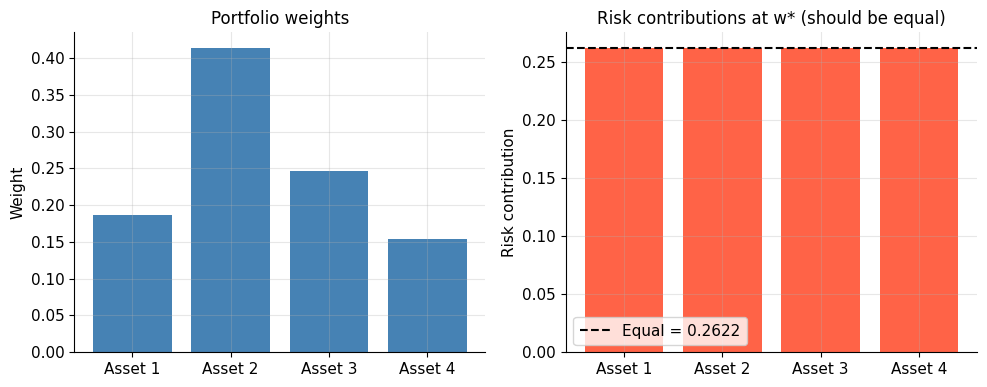

In [5]:
# Visual: weights and risk contributions
fig = plot_risk_contributions(w_star, Sigma, title='Risk contributions at w* (should be equal)')
savefig('fig1_risk_contributions')
plt.show()

## 1.2  The Augmented Jacobian H

By the Implicit Function Theorem, if the Jacobian
$$H = \frac{\partial G}{\partial z} = \begin{pmatrix} J & -\mathbf{1} \\ \mathbf{1}^\top & 0 \end{pmatrix}$$
is nonsingular at $z^* = (w^*, \lambda^*)$, then $w^*$ depends smoothly on $\Sigma$.

The block $J$ has entries:
$$J_{ij} = w_i \Sigma_{ij} + \delta_{ij} (\Sigma w)_i$$

In [6]:
# Compute the augmented Jacobian at the solution
H = compute_jacobian(w_star, Sigma)
print(f'Augmented Jacobian H  (shape {H.shape}):')
print(H)
print(f'\ndet(H) = {np.linalg.det(H):.4e}  (nonzero -> IFT applies)')
print(f'cond(H) = {np.linalg.cond(H):.2f}')

Augmented Jacobian H  (shape (5, 5)):
[[ 3.486894  0.319428 -1.361786  0.675478 -1.      ]
 [ 0.710728  1.204124 -0.524402  0.312205 -1.      ]
 [-1.800421 -0.311601  4.226375 -0.169964 -1.      ]
 [ 0.556692  0.115642 -0.105949  2.766468 -1.      ]
 [ 1.        1.        1.        1.        0.      ]]

det(H) = 6.6604e+01  (nonzero -> IFT applies)
cond(H) = 5.00


## 1.3  Two-Asset Closed Form

For $n = 2$:
$$w_1^* = \frac{\sigma_2}{\sigma_1 + \sigma_2}, \quad w_2^* = \frac{\sigma_1}{\sigma_1 + \sigma_2}$$

Correlation $\rho$ cancels — weights depend only on relative volatilities. This is the **inverse-volatility** portfolio.

In [7]:
sigma1, sigma2, rho = 0.15, 0.25, 0.3

# Closed form
w_cf = two_asset_risk_parity(sigma1, sigma2)
print(f'Closed form: w1={w_cf[0]:.6f}, w2={w_cf[1]:.6f}')

# Numerical solver
Sigma2 = np.array([[sigma1**2, rho*sigma1*sigma2],
                   [rho*sigma1*sigma2, sigma2**2]])
w_num, _ = solve_risk_parity(Sigma2)
print(f'Numerical:   w1={w_num[0]:.6f}, w2={w_num[1]:.6f}')
print(f'\nMax difference: {np.max(np.abs(w_cf - w_num)):.2e}')

Closed form: w1=0.625000, w2=0.375000
Numerical:   w1=0.625000, w2=0.375000

Max difference: 4.37e-10


Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig2_two_asset_correlation_independence.png


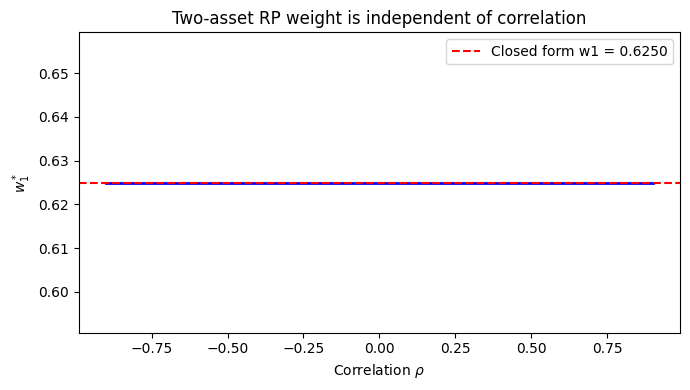

In [8]:
# Demonstrate correlation independence in n=2 case
rho_values = np.linspace(-0.9, 0.9, 100)
w1_values = []
for rho in rho_values:
    S = np.array([[sigma1**2, rho*sigma1*sigma2],
                  [rho*sigma1*sigma2, sigma2**2]])
    w, _ = solve_risk_parity(S)
    w1_values.append(w[0])

plt.figure(figsize=(7, 4))
plt.plot(rho_values, w1_values, 'b-', linewidth=2)
plt.axhline(w_cf[0], color='red', linestyle='--', label=f'Closed form w1 = {w_cf[0]:.4f}')
plt.xlabel(r'Correlation $\rho$')
plt.ylabel(r'$w_1^*$')
plt.title('Two-asset RP weight is independent of correlation')
plt.legend()
plt.tight_layout()
savefig('fig2_two_asset_correlation_independence')
plt.show()